# 8. Finale Evaluation auf dem Testdatensatz

In diesem Notebook werden die bisher besten Modellkandidaten zusammengefasst und auf dem zuvor zurückgehaltenen Testdatensatz evaluiert. Der Testdatensatz wurde in den vorherigen Notebooks nicht für Modellwahl, Hyperparameteroptimierung oder Feature-Entscheidungen verwendet. Dadurch dient diese Auswertung als finale, unverzerrte Leistungsprüfung.


## 8.1. Ziel der finalen Evaluation

Die finale Evaluation verfolgt drei Ziele:

1. Die bisher gespeicherten Modellkandidaten werden automatisch gefunden.
2. Die wichtigsten Validierungs- und Cross-Validation-Ergebnisse werden als Übersicht zusammengeführt.
3. Alle verfügbaren gespeicherten Modelle werden auf denselben Testdaten bewertet.

Als Hauptmetrik bleibt `Macro-F1` relevant, weil die Zielvariable `politikbereich` deutlich unausgewogen ist. Zusätzlich werden Weighted-F1, Balanced Accuracy, Accuracy, Metriken pro Klasse und Konfusionsmatrizen betrachtet.


In [9]:
from pathlib import Path
import re
import time
import sys

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd

from IPython.display import display
from joblib import load

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
)


def flatten_column(values):
    """Konvertiert eine einzelne Spalte in ein eindimensionales String-Array."""
    return np.asarray(values, dtype=object).ravel()


project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
processed_data_dir = project_root / "data" / "processed"
model_dir = project_root / "models"
report_dir = project_root / "reports" / "final_evaluation"
report_dir.mkdir(parents=True, exist_ok=True)

src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from model_evaluation import (
    combine_columns_as_text,
    display_model_evaluation_table,
    create_classification_report_df,
    plot_confusion_matrix,
)


mlflow_tracking_uri = (project_root / "mlruns").as_uri()
mlflow.set_tracking_uri(mlflow_tracking_uri)
mlflow.set_experiment("politikbereich_classifier_final_evaluation")

print("Projektverzeichnis:", project_root)
print("Report-Verzeichnis:", report_dir)


Projektverzeichnis: d:\toydev\schwarz-test
Report-Verzeichnis: d:\toydev\schwarz-test\reports\final_evaluation


## 8.2. Testdaten laden

Für die finale Evaluation wird ausschließlich `test_data.csv` verwendet. Die Trainingsdaten werden hier nicht erneut zur Modellwahl verwendet. Sie können lediglich als Referenz für Spaltennamen oder Klassenabdeckung dienen.


In [10]:
target_column = "politikbereich"

test_df = pd.read_csv(
    processed_data_dir / "test_data.csv",
    sep=";",
    index_col=0,
    encoding="utf-8",
)

X_test = test_df.drop(columns=[target_column]).copy()
y_test = test_df[target_column].copy()

print("Testdaten:", test_df.shape)
print("Anzahl Klassen im Testdatensatz:", y_test.nunique())

display(test_df.head())

test_class_distribution = (
    y_test.value_counts()
    .rename_axis("politikbereich")
    .reset_index(name="test_support")
)

display(test_class_distribution)


Testdaten: (11480, 28)
Anzahl Klassen im Testdatensatz: 32


,name,geber,art,jahr,anschrift,politikbereich,zweck,betrag,empfaengerid,name_normalized,...,anschrift_standardised,zweck_standardised,empfaengerid_standardised,name_standardised_before_modelling,geber_standardised_before_modelling,art_standardised_before_modelling,anschrift_standardised_before_modelling,zweck_standardised_before_modelling,empfaengerid_standardised_before_modelling,betrag_standardised
id,,,,,,,,,,,,,,,,,,,,,
77932,IBEB Initiative für Bildung und Erziehung Berl...,"Senatsverwaltung für Bildung, Jugend und Familie",Projektförderung,2021,"Wilhelmstraße 25-30, 13593 Berlin",Bildung,"DigitalPakt Schule, SifT, ZV I - Sofortausstat...",7032,hrb_163114,ibeb initiative für bildung und erziehung berl...,...,"wilhelmstrasse 25-30, 13593 berlin-bezirk span...","digitalpakt schule, sift, zv i - sofortausstat...",hrb_163114,ibeb initiative für bildung und erziehung berl...,"senatsverwaltung für bildung, jugend und familie",projektförderung,"Wilhelmstraße 25-30, 13593 Berlin-Bezirk Spand...","digitalpakt schule, sift, zv i - sofortausstat...",hrb_163114,8.858369
40720,Denk mal an Berlin e. V.,"Senatsverwaltung für Stadtentwicklung, Bauen u...",Projektförderung,2024,"Kantstraße 106 , 10627 Berlin","Bürgerschaftliches Engagement, Bürgerbeteiligung",werkstatt denkmal 2024,22200,vr_022759,denk mal an berlin e. v.,...,"kantstrasse 106, 10627 berlin, deutschland",werkstatt denkmal 2024,vr_022759,denkmal an berlin e. v.,"senatsverwaltung für stadtentwicklung, bauen u...",projektförderung,"Kantstraße 106, 10627 Berlin, Deutschland",werkstatt denkmal 2024,vr_022759,10.007893
124984,"Regionale Arbeitsstellen für Bildung, Integrat...","Senatsverwaltung für Integration, Arbeit und S...",Projektförderung,2021,"Boyenstraße\n 41, 10115 Berlin",Integration,Mehrsprachige Beratung und Vermittlung im Schu...,50336,vr_011745,"regionale arbeitsstellen für bildung, integrat...",...,"boyenstrasse 41, 10115 berlin, deutschland",mehrsprachige beratung und vermittlung im schu...,vr_011745,"regionale arbeitsstellen für bildung, integrat...","senatsverwaltung für integration, arbeit und s...",projektförderung,"Boyenstraße 41, 10115 Berlin, Deutschland",mehrsprachige beratung und vermittlung im schu...,vr_011745,10.826496
10507,Artikel 1 - Initiative für Menschenwürde e. V.,Bezirksamt Mitte,Projektförderung,2022,"Schlüterstraße 42, 10707 Berlin",Stadtentwicklung,FF Radikal Respektvoll II,89998,vr_034512,artikel 1 - initiative für menschenwürde e. v.,...,"schlüterstrasse 42, 10707 berlin-bezirk charlo...",ff radikal respektvoll ii,vr_034512,artikel 1 – initiative für menschenwürde e. v.,bezirksamt mitte,projektförderung,"Schlüterstraße 42, 10707 Berlin-Bezirk Charlot...",ff radikal respektvoll ii,vr_034512,11.407554
129994,Schulstiftung der Evangelischen Kirche Berlin-...,"Senatsverwaltung für Bildung, Jugend und Familie",Projektförderung,2022,"Georgenkirchstraße 69/70 , 10249 Berlin",Bildung,"DigitalPakt Schule, SifT, ZV I - Sofortausstat...",8910,sör_100016,schulstiftung der evangelischen kirche berlin-...,...,"georgenkirchstrasse 69-70, 10249 berlin-bezirk...","digitalpakt schule, sift, zv i - sofortausstat...",sör_100016,evangelische schulstiftung in der ekbo,"senatsverwaltung für bildung, jugend und familie",projektförderung,"Georgenkirchstraße 69-70, 10249 Berlin-Bezirk ...","digitalpakt schule, sift, zv i - sofortausstat...",sör_100016,9.095042


,politikbereich,test_support
0,Wirtschaft,2270
1,Arbeit,1561
2,Sport,1208
3,Jugend,1199
4,Kultur,938
5,Bildung,674
6,Soziales,572
7,Gesundheit,565
8,"Bürgerschaftliches Engagement, Bürgerbeteiligung",351
9,Integration,344


## 8.3. Bisherige Modellkandidaten zusammenfassen

Die folgende Übersicht sammelt die bereits gespeicherten Ergebnisse aus Baseline, Ablation, Optuna und erweiterten NLP-Modellen. Die Tabelle dient nur zur Orientierung. Die finale Entscheidung wird anschließend anhand der Testdaten getroffen.


In [11]:
def first_existing_value(row, columns):
    """Gibt den ersten vorhandenen Wert aus mehreren möglichen Spalten zurück."""
    for column in columns:
        if column in row.index and pd.notna(row[column]):
            return row[column]
    return pd.NA


def read_result_table(
    path,
    source_name,
    score_type,
):
    if not path.exists():
        return pd.DataFrame()

    result = pd.read_csv(
        path,
        sep=";",
        encoding="utf-8",
    )
    result["Ergebnisquelle"] = source_name
    result["Scoretyp"] = score_type
    result["Datei"] = path.name

    return result


def normalize_result_row(row):
    """Vereinheitlicht unterschiedlich aufgebaute Ergebnisdateien."""
    model_name = first_existing_value(
        row,
        [
            "Modell",
            "model",
            "Basis_Modell",
            "Ablation",
        ],
    )

    experiment = first_existing_value(
        row,
        [
            "Ablation",
            "Experimenttyp",
            "Scoretyp",
        ],
    )

    model_path = first_existing_value(
        row,
        ["model_path"],
    )

    model_exists = (
        Path(str(model_path)).exists()
        if pd.notna(model_path)
        else pd.NA
    )

    return {
        "Quelle": row.get("Ergebnisquelle", pd.NA),
        "Datei": row.get("Datei", pd.NA),
        "Scoretyp": row.get("Scoretyp", pd.NA),
        "Modell": model_name,
        "Experiment": experiment,
        "Macro-F1": first_existing_value(
            row,
            [
                "test_macro_f1",
                "test_macro_f1_mean",
                "val_macro_f1",
                "val_macro_f1_mean",
                "macro_f1",
                "macro_f1_mean",
                "objective_value",
            ],
        ),
        "Macro-F1 Std": first_existing_value(
            row,
            [
                "test_macro_f1_std",
                "val_macro_f1_std",
                "macro_f1_std",
            ],
        ),
        "Weighted-F1": first_existing_value(
            row,
            [
                "test_weighted_f1",
                "test_weighted_f1_mean",
                "val_weighted_f1",
                "val_weighted_f1_mean",
                "weighted_f1",
                "weighted_f1_mean",
            ],
        ),
        "Balanced Accuracy": first_existing_value(
            row,
            [
                "test_balanced_accuracy",
                "test_balanced_accuracy_mean",
                "val_balanced_accuracy",
                "val_balanced_accuracy_mean",
                "balanced_accuracy",
                "balanced_accuracy_mean",
            ],
        ),
        "Accuracy": first_existing_value(
            row,
            [
                "test_accuracy",
                "test_accuracy_mean",
                "val_accuracy",
                "val_accuracy_mean",
                "accuracy",
                "accuracy_mean",
            ],
        ),
        "Trainingszeit Sekunden": first_existing_value(
            row,
            [
                "training_time_seconds",
                "fit_time_total_seconds",
                "fit_time_mean_seconds",
            ],
        ),
        "Trial": first_existing_value(
            row,
            ["trial_number"],
        ),
        "Model gespeichert": model_exists,
        "Modelpfad": model_path,
    }


def create_model_candidate_row(
    model_name,
    model_type,
    model_path,
    source_name,
):
    return {
        "Quelle": source_name,
        "Datei": model_path.name,
        "Scoretyp": "Gespeichertes Modell",
        "Modell": model_name,
        "Experiment": model_type,
        "Macro-F1": pd.NA,
        "Macro-F1 Std": pd.NA,
        "Weighted-F1": pd.NA,
        "Balanced Accuracy": pd.NA,
        "Accuracy": pd.NA,
        "Trainingszeit Sekunden": pd.NA,
        "Trial": pd.NA,
        "Model gespeichert": model_path.exists(),
        "Modelpfad": str(model_path),
    }


candidate_result_sources = [
    (
        processed_data_dir / "baseline_cv_results.csv",
        "Baseline Cross-Validation",
        "Cross-Validation",
    ),
    (
        processed_data_dir / "ablation_cv_results.csv",
        "Ablation und Repräsentation",
        "Cross-Validation",
    ),
    (
        processed_data_dir / "optuna_tuning_results.csv",
        "Optuna klassische Modelle",
        "Validierung/CV während Tuning",
    ),
    (
        processed_data_dir / "optuna_extended_nlp_results.csv",
        "Optuna neue NLP-Modelle",
        "Validierung während Tuning",
    ),
    (
        processed_data_dir / "optuna_fasttext_results.csv",
        "Optuna fastText",
        "Validierung während Tuning",
    ),
    (
        model_dir / "fasttext" / "fasttext_summary.csv",
        "fastText Baseline",
        "Interner Validierungssplit",
    ),
    (
        model_dir / "bert" / "bert_summary.csv",
        "BERT Baseline",
        "Interner Validierungssplit",
    ),
    (
        project_root / "reports" / "ensemble" / "ensemble_cv_results.csv",
        "Ensemble Cross-Validation",
        "Cross-Validation",
    ),
]

result_tables = [
    read_result_table(
        path,
        source_name,
        score_type,
    )
    for path, source_name, score_type in candidate_result_sources
]

candidate_results_raw = pd.concat(
    [table for table in result_tables if not table.empty],
    ignore_index=True,
    sort=False,
) if any(not table.empty for table in result_tables) else pd.DataFrame()

if not candidate_results_raw.empty:
    normalized_result_rows = [
        normalize_result_row(row)
        for _, row in candidate_results_raw.iterrows()
    ]
else:
    normalized_result_rows = []

candidate_model_paths = []

candidate_model_paths.extend(
    [
        (
            path.stem,
            "scikit-learn",
            path,
            "Gespeichertes Baseline-Modell",
        )
        for path in sorted(model_dir.glob("baseline/*.joblib"))
    ]
)

candidate_model_paths.extend(
    [
        (
            path.stem,
            "scikit-learn",
            path,
            "Gespeichertes Optuna-Modell",
        )
        for path in sorted(model_dir.glob("optuna/*.joblib"))
    ]
)

candidate_model_paths.extend(
    [
        (
            path.stem,
            "scikit-learn",
            path,
            "Gespeichertes Kontrollmodell",
        )
        for path in sorted(model_dir.glob("control_comparison/*.joblib"))
    ]
)

candidate_model_paths.extend(
    [
        (
            path.stem,
            "scikit-learn",
            path,
            "Gespeichertes Ensemble-Modell",
        )
        for path in sorted(model_dir.glob("ensemble/*.joblib"))
    ]
)

candidate_model_paths.extend(
    [
        (
            path.stem,
            "CatBoost",
            path,
            "Gespeichertes CatBoost-Modell",
        )
        for path in sorted(model_dir.glob("baseline/*.cbm"))
    ]
)

fasttext_model_candidates = [
    model_dir / "optuna" / "new_nlp_models" / "fasttext" / "best_fasttext_politikbereich.bin",
    model_dir / "fasttext" / "fasttext_politikbereich.bin",
]

candidate_model_paths.extend(
    [
        (
            path.stem,
            "fastText",
            path,
            "Gespeichertes fastText-Modell",
        )
        for path in fasttext_model_candidates
        if path.exists()
    ]
)

bert_model_candidates = [
    model_dir / "bert" / "bert_politikbereich",
    model_dir / "optuna" / "new_nlp_models" / "bert" / "best_bert_politikbereich",
]

candidate_model_paths.extend(
    [
        (
            path.name,
            "BERT",
            path,
            "Gespeichertes BERT-Modell",
        )
        for path in bert_model_candidates
        if path.exists()
    ]
)

model_candidate_rows = [
    create_model_candidate_row(
        model_name,
        model_type,
        model_path,
        source_name,
    )
    for model_name, model_type, model_path, source_name in candidate_model_paths
]

candidate_summary = pd.DataFrame(
    normalized_result_rows + model_candidate_rows
)

if candidate_summary.empty:
    print("Keine gespeicherten Ergebnisdateien oder Modelle gefunden.")
else:
    numeric_columns = [
        "Macro-F1",
        "Macro-F1 Std",
        "Weighted-F1",
        "Balanced Accuracy",
        "Accuracy",
        "Trainingszeit Sekunden",
    ]

    for column in numeric_columns:
        candidate_summary[column] = pd.to_numeric(
            candidate_summary[column],
            errors="coerce",
        )

    candidate_summary["Model gespeichert"] = (
        candidate_summary["Model gespeichert"]
        .astype("boolean")
        .fillna(False)
        .astype(bool)
    )

    candidate_summary["_has_score"] = candidate_summary["Macro-F1"].notna()
    candidate_summary["_model_sort"] = candidate_summary["Model gespeichert"].astype(int)
    candidate_summary["_score_sort"] = candidate_summary["Macro-F1"].fillna(-1)

    candidate_summary = (
        candidate_summary
        .sort_values(
            [
                "_has_score",
                "_score_sort",
                "_model_sort",
                "Modell",
            ],
            ascending=[False, False, False, True],
        )
        .drop(
            columns=[
                "_has_score",
                "_model_sort",
                "_score_sort",
            ]
        )
        .reset_index(drop=True)
    )

    # Für die Übersicht sollen Optuna-Studien nicht mit allen Trials
    # erscheinen. Pro Quelle und Modell wird nur der beste Trial gezeigt.
    optuna_or_trial_mask = candidate_summary["Trial"].notna()

    best_trial_rows = (
        candidate_summary.loc[optuna_or_trial_mask]
        .sort_values("Macro-F1", ascending=False)
        .groupby(["Quelle", "Modell"], dropna=False)
        .head(1)
    )

    non_trial_rows = candidate_summary.loc[~optuna_or_trial_mask]

    candidate_summary_clean = (
        pd.concat(
            [
                non_trial_rows,
                best_trial_rows,
            ],
            ignore_index=True,
        )
        .drop_duplicates(
            subset=[
                "Scoretyp",
                "Modell",
                "Experiment",
                "Macro-F1",
                "Weighted-F1",
                "Balanced Accuracy",
                "Accuracy",
            ],
            keep="first",
        )
        .sort_values(
            [
                "Macro-F1",
                "Model gespeichert",
                "Quelle",
                "Modell",
            ],
            ascending=[False, False, True, True],
            na_position="last",
        )
        .reset_index(drop=True)
    )

    display_columns = [
        "Quelle",
        "Scoretyp",
        "Modell",
        "Experiment",
        "Macro-F1",
        "Macro-F1 Std",
        "Weighted-F1",
        "Balanced Accuracy",
        "Accuracy",
        "Trainingszeit Sekunden",
        "Trial",
        "Model gespeichert",
        "Modelpfad",
    ]

    candidate_display = candidate_summary_clean[display_columns].copy()

    metric_display_columns = [
        "Macro-F1",
        "Macro-F1 Std",
        "Weighted-F1",
        "Balanced Accuracy",
        "Accuracy",
        "Trainingszeit Sekunden",
    ]

    for column in metric_display_columns:
        candidate_display[column] = candidate_display[column].round(4)

    candidate_display = candidate_display.fillna("-")

    display(candidate_display)


,Quelle,Scoretyp,Modell,Experiment,Macro-F1,Macro-F1 Std,Weighted-F1,Balanced Accuracy,Accuracy,Trainingszeit Sekunden,Trial,Model gespeichert,Modelpfad
0,Ensemble Cross-Validation,Cross-Validation,Hard Voting tuned balanced mix,Cross-Validation,0.8581,0.005,0.9406,0.8574,0.9406,836.88,-,False,-
1,Ensemble Cross-Validation,Cross-Validation,Hard Voting tuned rare-class focus,Cross-Validation,0.8579,0.0046,0.9405,0.8575,0.9405,952.34,-,False,-
2,Optuna klassische Modelle,Validierung/CV während Tuning,Linear SVC unweighted,Validierung/CV während Tuning,0.8575,0.0142,0.9418,0.8415,0.9425,16.13,6.0,False,-
3,Optuna klassische Modelle,Validierung/CV während Tuning,SGD hinge,Validierung/CV während Tuning,0.8523,0.0029,0.9414,0.8554,0.9413,12.08,27.0,False,-
4,Optuna klassische Modelle,Validierung/CV während Tuning,Linear SVC balanced,Validierung/CV während Tuning,0.8516,0.0102,0.9395,0.8593,0.9391,16.14,19.0,False,-
5,Optuna neue NLP-Modelle,Validierung während Tuning,fastText,Validierung während Tuning,0.8247,0.0151,0.9332,0.8063,0.9338,42.34,15.0,False,-
6,Baseline Cross-Validation,Cross-Validation,Linear SVC unweighted,Cross-Validation,0.8233,0.0189,0.9251,0.7945,0.9267,97.31,-,True,d:\toydev\schwarz-test\models\baseline\linear_...
7,Ablation und Repräsentation,Cross-Validation,SGD hinge balanced,Text + categorical,0.815,0.0088,0.9222,0.8508,0.9208,22.14,-,True,d:\toydev\schwarz-test\models\ablation\sgd_hin...
8,Baseline Cross-Validation,Cross-Validation,Linear SVC balanced,Cross-Validation,0.8145,0.0072,0.9137,0.8429,0.9123,114.17,-,True,d:\toydev\schwarz-test\models\baseline\linear_...
9,Ablation und Repräsentation,Cross-Validation,SGD hinge balanced,Full model,0.8064,0.0326,0.9198,0.8382,0.9179,24.07,-,True,d:\toydev\schwarz-test\models\ablation\sgd_hin...


Diese Übersicht fasst Validierungs-, Cross-Validation- und gespeicherte Modellkandidaten in einer gemeinsamen Struktur zusammen. Die Werte sind jedoch nicht identisch zu interpretieren: Cross-Validation- und Validierungswerte dienen der Modellauswahl, w?hrend die finale Bewertung erst auf dem separaten Testdatensatz erfolgt.


## 8.4. Hilfsfunktionen für die Testevaluation

Alle Modelle werden mit denselben Testdaten und denselben Metriken bewertet. Dadurch sind die Ergebnisse direkt vergleichbar. Für jedes Modell werden außerdem ein klassenbezogener Report und optional eine Konfusionsmatrix erzeugt.


In [12]:
def create_evaluation_summary(
    model_name,
    y_true,
    y_pred,
    model_type,
    model_path=None,
    prediction_time_seconds=None,
):
    return {
        "model_name": model_name,
        "model_type": model_type,
        "test_rows": len(y_true),
        "test_accuracy": accuracy_score(y_true, y_pred),
        "test_macro_f1": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        ),
        "test_weighted_f1": f1_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0,
        ),
        "test_balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "prediction_time_seconds": prediction_time_seconds,
        "model_path": str(model_path) if model_path is not None else None,
    }


def safe_filename(value):
    return re.sub(
        r"[^0-9a-zA-Z_-]+",
        "_",
        str(value),
    ).strip("_").lower()


## 8.5. Gespeicherte scikit-learn-Modelle evaluieren

Die scikit-learn-Modelle wurden als `joblib`-Dateien gespeichert. Dazu gehören aktuell das beste Optuna-Modell sowie gespeicherte Kontrollmodelle. Die Modelle enthalten ihre jeweilige Vorverarbeitung, daher können sie direkt auf dem Test-DataFrame angewendet werden.


In [13]:
sklearn_model_paths = sorted(
    [
        *model_dir.glob("baseline/*.joblib"),
        *model_dir.glob("optuna/*.joblib"),
        *model_dir.glob("control_comparison/*.joblib"),
        *model_dir.glob("ensemble/*.joblib"),
    ]
)

print("Gefundene scikit-learn-Modelle:", len(sklearn_model_paths))
for path in sklearn_model_paths:
    print("-", path)

final_evaluation_rows = []
classification_reports = {}
predictions_by_model = {}

for sklearn_model_path in sklearn_model_paths:
    model_name = sklearn_model_path.stem

    try:
        model = load(sklearn_model_path)

        start_time = time.perf_counter()
        y_pred = model.predict(X_test)
        prediction_time = time.perf_counter() - start_time

        summary = create_evaluation_summary(
            model_name=model_name,
            y_true=y_test,
            y_pred=y_pred,
            model_type="scikit-learn",
            model_path=sklearn_model_path,
            prediction_time_seconds=round(prediction_time, 2),
        )
        final_evaluation_rows.append(summary)

        report = create_classification_report_df(y_test, y_pred)
        classification_reports[model_name] = report
        predictions_by_model[model_name] = y_pred

        report_path = report_dir / f"classification_report_{safe_filename(model_name)}.csv"
        report.to_csv(
            report_path,
            sep=";",
            encoding="utf-8",
        )

        with mlflow.start_run(
            run_name=f"final evaluation - {model_name}",
            nested=True,
        ):
            mlflow.log_param("model_name", model_name)
            mlflow.log_param("model_type", "scikit-learn")
            mlflow.log_param("model_path", str(sklearn_model_path))
            for metric_name, metric_value in summary.items():
                if isinstance(metric_value, (int, float)):
                    mlflow.log_metric(metric_name, metric_value)
            mlflow.log_artifact(str(report_path))

    except Exception as error:
        print(f"Modell konnte nicht evaluiert werden: {sklearn_model_path}")
        print(type(error).__name__, error)


Gefundene scikit-learn-Modelle: 11
- d:\toydev\schwarz-test\models\baseline\complement_naive_bayes_text_only_37facd42fb0e.joblib
- d:\toydev\schwarz-test\models\baseline\dummy_classifier_60e1d6e221f7.joblib
- d:\toydev\schwarz-test\models\baseline\linear_svc_balanced_90d9bfe9ec68.joblib
- d:\toydev\schwarz-test\models\baseline\linear_svc_unweighted_782ddb7fe4fe.joblib
- d:\toydev\schwarz-test\models\baseline\logistic_regression_balanced_5df19ae6c78e.joblib
- d:\toydev\schwarz-test\models\baseline\sgd_hinge_balanced_aab96a884cf6.joblib
- d:\toydev\schwarz-test\models\baseline\sgd_log_loss_balanced_b21846c9b6e5.joblib
- d:\toydev\schwarz-test\models\control_comparison\logistic_regression_balanced__full_model.joblib
- d:\toydev\schwarz-test\models\ensemble\hard_voting_tuned_balanced_mix.joblib
- d:\toydev\schwarz-test\models\optuna\best_optuna_linear_svc_unweighted.joblib
- d:\toydev\schwarz-test\models\optuna\best_optuna_sgd_hinge.joblib


## 8.6. CatBoost-Modell evaluieren, falls vorhanden

CatBoost wird separat evaluiert, weil das Modell nicht als scikit-learn-`Pipeline`, sondern im nativen CatBoost-Format gespeichert wird. Für die Vorhersage werden dieselben Text-, Kategorie- und Zahlenmerkmale verwendet wie in der CatBoost-Baseline.


In [14]:
catboost_model_paths = sorted(model_dir.glob("baseline/*.cbm"))

if not catboost_model_paths:
    print("Kein gespeichertes CatBoost-Modell gefunden.")
else:
    try:
        from catboost import CatBoostClassifier, Pool

        catboost_text_features = [
            "name_standardised",
            "geber_standardised",
            "anschrift_standardised",
            "zweck_standardised",
        ]
        catboost_categorical_features = [
            "art_standardised",
            "jahr",
        ]
        catboost_numeric_features = [
            "betrag",
        ]
        catboost_feature_columns = (
            catboost_text_features
            + catboost_numeric_features
            + catboost_categorical_features
        )
        catboost_feature_columns = [
            column
            for column in catboost_feature_columns
            if column in X_test.columns
        ]

        def prepare_catboost_features(dataframe):
            """Bereitet Testdaten für CatBoost vor."""
            result = dataframe[catboost_feature_columns].copy()

            for column in catboost_text_features + catboost_categorical_features:
                if column in result.columns:
                    result[column] = (
                        result[column]
                        .fillna("")
                        .astype(str)
                    )

            for column in catboost_numeric_features:
                if column in result.columns:
                    result[column] = pd.to_numeric(
                        result[column],
                        errors="coerce",
                    )

            return result

        X_test_catboost = prepare_catboost_features(X_test)
        test_pool = Pool(
            data=X_test_catboost,
            cat_features=[
                column
                for column in catboost_categorical_features
                if column in X_test_catboost.columns
            ],
            text_features=[
                column
                for column in catboost_text_features
                if column in X_test_catboost.columns
            ],
        )

        for catboost_model_path in catboost_model_paths:
            model_name = catboost_model_path.stem
            catboost_model = CatBoostClassifier()
            catboost_model.load_model(str(catboost_model_path))

            start_time = time.perf_counter()
            y_pred = pd.Series(
                catboost_model.predict(test_pool).ravel(),
                index=y_test.index,
            )
            prediction_time = time.perf_counter() - start_time

            summary = create_evaluation_summary(
                model_name=model_name,
                y_true=y_test,
                y_pred=y_pred,
                model_type="CatBoost",
                model_path=catboost_model_path,
                prediction_time_seconds=round(prediction_time, 2),
            )
            final_evaluation_rows.append(summary)

            report = create_classification_report_df(y_test, y_pred)
            classification_reports[model_name] = report
            predictions_by_model[model_name] = y_pred

            report_path = report_dir / f"classification_report_{safe_filename(model_name)}.csv"
            report.to_csv(report_path, sep=";", encoding="utf-8")

            with mlflow.start_run(
                run_name=f"final evaluation - {model_name}",
                nested=True,
            ):
                mlflow.log_param("model_name", model_name)
                mlflow.log_param("model_type", "CatBoost")
                mlflow.log_param("model_path", str(catboost_model_path))
                for metric_name, metric_value in summary.items():
                    if isinstance(metric_value, (int, float)):
                        mlflow.log_metric(metric_name, metric_value)
                mlflow.log_artifact(str(report_path))

    except ImportError:
        print(
            "CatBoost ist nicht installiert. "
            "Die CatBoost-Testevaluation wird übersprungen."
        )
    except Exception as error:
        print("CatBoost konnte nicht evaluiert werden.")
        print(type(error).__name__, error)


## 8.7. fastText-Modell evaluieren, falls vorhanden

fastText wird separat evaluiert, weil es kein scikit-learn-Objekt ist. Für die Vorhersage wird derselbe markierte Text erzeugt, der auch in der fastText- und BERT-Vorbereitung verwendet wurde. Falls das Paket `fasttext` in der aktuellen Umgebung nicht installiert ist, wird dieser Schritt übersprungen.


In [15]:
fasttext_feature_columns = [
    "name_standardised",
    "geber_standardised",
    "anschrift_standardised",
    "zweck_standardised",
    "art_standardised",
    "jahr",
]

fasttext_feature_columns = [
    column
    for column in fasttext_feature_columns
    if column in X_test.columns
]

X_test_fasttext_text = combine_columns_as_text(
    X_test,
    fasttext_feature_columns,
)

fasttext_candidates = [
    model_dir / "optuna" / "new_nlp_models" / "fasttext" / "best_fasttext_politikbereich.bin",
    model_dir / "fasttext" / "fasttext_politikbereich.bin",
]

fasttext_model_path = next(
    (path for path in fasttext_candidates if path.exists()),
    None,
)

if fasttext_model_path is None:
    print("Kein gespeichertes fastText-Modell gefunden.")
else:
    try:
        import fasttext

        label_mapping_candidates = [
            fasttext_model_path.parent / "fasttext_label_mapping.csv",
            model_dir / "fasttext" / "fasttext_label_mapping.csv",
        ]
        label_mapping_path = next(
            (path for path in label_mapping_candidates if path.exists()),
            None,
        )

        if label_mapping_path is None:
            raise FileNotFoundError("fastText-Labelmapping wurde nicht gefunden.")

        fasttext_label_mapping = pd.read_csv(
            label_mapping_path,
            sep=";",
            encoding="utf-8",
        )
        fasttext_label_to_class = dict(
            zip(
                fasttext_label_mapping["fasttext_label"],
                fasttext_label_mapping["politikbereich"],
            )
        )

        fasttext_model = fasttext.load_model(str(fasttext_model_path))

        start_time = time.perf_counter()
        predicted_labels, _ = fasttext_model.predict(
            X_test_fasttext_text.tolist(),
            k=1,
        )
        prediction_time = time.perf_counter() - start_time

        fasttext_y_pred = pd.Series(
            [
                fasttext_label_to_class.get(label_group[0], label_group[0])
                if len(label_group) > 0
                else None
                for label_group in predicted_labels
            ],
            index=y_test.index,
        )

        model_name = fasttext_model_path.stem
        summary = create_evaluation_summary(
            model_name=model_name,
            y_true=y_test,
            y_pred=fasttext_y_pred,
            model_type="fastText",
            model_path=fasttext_model_path,
            prediction_time_seconds=round(prediction_time, 2),
        )
        final_evaluation_rows.append(summary)

        report = create_classification_report_df(y_test, fasttext_y_pred)
        classification_reports[model_name] = report
        predictions_by_model[model_name] = fasttext_y_pred

        report_path = report_dir / f"classification_report_{safe_filename(model_name)}.csv"
        report.to_csv(report_path, sep=";", encoding="utf-8")

        with mlflow.start_run(
            run_name=f"final evaluation - {model_name}",
            nested=True,
        ):
            mlflow.log_param("model_name", model_name)
            mlflow.log_param("model_type", "fastText")
            mlflow.log_param("model_path", str(fasttext_model_path))
            for metric_name, metric_value in summary.items():
                if isinstance(metric_value, (int, float)):
                    mlflow.log_metric(metric_name, metric_value)
            mlflow.log_artifact(str(report_path))

    except ImportError:
        print(
            "fastText ist nicht installiert. "
            "Die fastText-Testevaluation wird übersprungen."
        )
    except Exception as error:
        print("fastText konnte nicht evaluiert werden.")
        print(type(error).__name__, error)


## 8.8. BERT-Modell evaluieren, falls vorhanden

Ein gespeichertes BERT-Modell wird nur evaluiert, wenn Modellordner, Tokenizer und Labelencoder vorhanden sind und die benötigten Pakete installiert sind. Dieser Schritt ist optional, weil BERT nicht in jeder Umgebung trainiert wurde.


In [16]:
bert_model_candidates = [
    model_dir / "bert" / "bert_politikbereich",
    model_dir
    / "optuna"
    / "new_nlp_models"
    / "bert"
    / "best_bert_politikbereich",
]

bert_model_path = next(
    (
        path
        for path in bert_model_candidates
        if path.exists()
    ),
    None,
)

if bert_model_path is None:
    print("Kein gespeichertes BERT-Modell gefunden.")
else:
    try:
        import torch
        from transformers import (
            AutoModelForSequenceClassification,
            AutoTokenizer,
        )

        label_encoder_candidates = [
            bert_model_path.parent / "bert_label_encoder.joblib",
            model_dir / "bert" / "bert_label_encoder.joblib",
            model_dir
            / "optuna"
            / "new_nlp_models"
            / "bert"
            / "bert_label_encoder.joblib",
        ]

        bert_label_encoder_path = next(
            (
                path
                for path in label_encoder_candidates
                if path.exists()
            ),
            None,
        )

        if bert_label_encoder_path is None:
            raise FileNotFoundError(
                "BERT-Labelencoder wurde nicht gefunden."
            )

        bert_label_encoder = load(bert_label_encoder_path)

        bert_tokenizer = AutoTokenizer.from_pretrained(
            str(bert_model_path)
        )
        bert_model = (
            AutoModelForSequenceClassification
            .from_pretrained(str(bert_model_path))
        )

        device = torch.device(
            "cuda"
            if torch.cuda.is_available()
            else "cpu"
        )

        bert_model.to(device)
        bert_model.eval()

        bert_feature_columns = [
            "name_standardised",
            "geber_standardised",
            "anschrift_standardised",
            "zweck_standardised",
            "art_standardised",
            "jahr",
        ]

        bert_feature_columns = [
            column
            for column in bert_feature_columns
            if column in X_test.columns
        ]

        X_test_bert_text = combine_columns_as_text(
            X_test,
            bert_feature_columns,
        )

        bert_predictions = []
        batch_size = 32
        start_time = time.perf_counter()

        with torch.no_grad():
            for start_index in range(
                0,
                len(X_test_bert_text),
                batch_size,
            ):
                batch_texts = (
                    X_test_bert_text
                    .iloc[start_index:start_index + batch_size]
                    .tolist()
                )

                encoded_batch = bert_tokenizer(
                    batch_texts,
                    truncation=True,
                    padding=True,
                    max_length=256,
                    return_tensors="pt",
                )

                encoded_batch = {
                    key: value.to(device)
                    for key, value in encoded_batch.items()
                }

                outputs = bert_model(**encoded_batch)
                batch_predictions = (
                    outputs
                    .logits
                    .argmax(dim=-1)
                    .cpu()
                    .numpy()
                )
                bert_predictions.extend(
                    batch_predictions.tolist()
                )

        prediction_time = time.perf_counter() - start_time

        bert_y_pred = pd.Series(
            bert_label_encoder.inverse_transform(
                bert_predictions
            ),
            index=y_test.index,
        )

        model_name = bert_model_path.name

        summary = create_evaluation_summary(
            model_name=model_name,
            y_true=y_test,
            y_pred=bert_y_pred,
            model_type="BERT",
            model_path=bert_model_path,
            prediction_time_seconds=round(prediction_time, 2),
        )
        final_evaluation_rows.append(summary)

        report = create_classification_report_df(
            y_test,
            bert_y_pred,
        )
        classification_reports[model_name] = report
        predictions_by_model[model_name] = bert_y_pred

        report_path = (
            report_dir
            / f"classification_report_{safe_filename(model_name)}.csv"
        )
        report.to_csv(
            report_path,
            sep=";",
            encoding="utf-8",
        )

        with mlflow.start_run(
            run_name=f"final evaluation - {model_name}",
            nested=True,
        ):
            mlflow.log_param("model_name", model_name)
            mlflow.log_param("model_type", "BERT")
            mlflow.log_param("model_path", str(bert_model_path))
            mlflow.log_param("device", str(device))
            mlflow.log_param(
                "feature_columns",
                ", ".join(bert_feature_columns),
            )

            for metric_name, metric_value in summary.items():
                if isinstance(metric_value, (int, float)):
                    mlflow.log_metric(
                        metric_name,
                        metric_value,
                    )

            mlflow.log_artifact(str(report_path))

    except ImportError:
        print(
            "transformers und/oder torch sind nicht installiert. "
            "Die BERT-Testevaluation wird übersprungen."
        )
    except Exception as error:
        print("BERT konnte nicht evaluiert werden.")
        print(type(error).__name__, error)

d:\toydev\schwarz-test\.venv\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.6.1 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

## 8.9. Finale Testergebnisse vergleichen

Die folgende Tabelle enthält nur Ergebnisse auf dem finalen Testdatensatz. Das beste Modell wird primär anhand von `test_macro_f1` betrachtet. Zusätzlich sollten Weighted-F1, Balanced Accuracy und die klassenbezogenen Reports geprüft werden.


In [17]:
if final_evaluation_rows:
    final_evaluation_results = (
        pd.DataFrame(final_evaluation_rows)
        .sort_values(
            "test_macro_f1",
            ascending=False,
        )
        .reset_index(drop=True)
    )
else:
    final_evaluation_results = pd.DataFrame()

final_evaluation_results_path = report_dir / "final_test_evaluation_results.csv"
final_evaluation_results.to_csv(
    final_evaluation_results_path,
    index=False,
    sep=";",
    encoding="utf-8",
)

print("Gespeichert:", final_evaluation_results_path)

if not final_evaluation_results.empty:
    display_model_evaluation_table(
        final_evaluation_results,
        model_column_candidates=[
            "model_name",
        ],
        include_columns=[
            "model_type",
            "test_rows",
            "prediction_time_seconds",
        ],
        metric_prefixes=[
            "test_",
        ],
        sort_by="test_macro_f1",
        ascending=False,
    )

    best_test_model_name = final_evaluation_results.iloc[0]["model_name"]
    print(
        "Bestes Modell auf dem Testdatensatz:",
        best_test_model_name,
    )
    print(
        "Test Macro-F1:",
        final_evaluation_results.iloc[0]["test_macro_f1"],
    )
else:
    display(final_evaluation_results)


Gespeichert: d:\toydev\schwarz-test\reports\final_evaluation\final_test_evaluation_results.csv


,model_name,model_type,test_rows,prediction_time_seconds,test_accuracy,test_macro_f1,test_weighted_f1,test_balanced_accuracy
0,best_optuna_linear_svc_unweighted,scikit-learn,11480,0.72,0.951220,0.836137,0.950662,0.814674
1,hard_voting_tuned_balanced_mix,scikit-learn,11480,1.97,0.949652,0.831458,0.949769,0.826074
2,linear_svc_balanced_90d9bfe9ec68,scikit-learn,11480,0.70,0.926132,0.819534,0.927377,0.833121
3,linear_svc_unweighted_782ddb7fe4fe,scikit-learn,11480,0.80,0.939460,0.811563,0.938301,0.779228
4,best_fasttext_politikbereich,fastText,11480,0.25,0.945122,0.808084,0.944759,0.791021
5,best_optuna_sgd_hinge,scikit-learn,11480,0.72,0.947213,0.799919,0.947517,0.811271
6,sgd_hinge_balanced_aab96a884cf6,scikit-learn,11480,0.91,0.927439,0.783684,0.929852,0.826323
7,bert_politikbereich,BERT,11480,168.60,0.933101,0.777187,0.932217,0.769743
8,sgd_log_loss_balanced_b21846c9b6e5,scikit-learn,11480,0.70,0.883798,0.765764,0.886621,0.798138
9,complement_naive_bayes_text_only_37facd42fb0e,scikit-learn,11480,0.69,0.869512,0.634940,0.860540,0.590859


Bestes Modell auf dem Testdatensatz: best_optuna_linear_svc_unweighted
Test Macro-F1: 0.8361373963911298


Die finale Tabelle ist nach `test_macro_f1` sortiert und bewertet alle verfügbaren gespeicherten Modelle auf demselben zurückgehaltenen Testdatensatz. Diese Werte sind daher aussagekräftiger für die erwartete Generalisierungsleistung als die vorherigen Validierungs- oder Cross-Validation-Ergebnisse.


## 8.10. Klassenbezogenen Report des besten Modells anzeigen

Der aggregierte Score allein reicht bei ungleichen Klassen nicht aus. Deshalb wird für das beste Modell der Report pro Klasse angezeigt. Besonders relevant sind Klassen mit niedrigem Support oder sehr niedrigen F1-Werten.


In [18]:
if not final_evaluation_results.empty:
    best_test_model_name = final_evaluation_results.iloc[0]["model_name"]
    best_report = classification_reports[best_test_model_name]

    display(best_report)

    low_f1_classes = (
        best_report
        .drop(index=["accuracy", "macro avg", "weighted avg"], errors="ignore")
        .reset_index(names="politikbereich")
        .sort_values(["f1-score", "support"])
    )

    print("Klassen mit den niedrigsten F1-Werten:")
    display(low_f1_classes.head(10))
else:
    print("Keine Evaluationsergebnisse vorhanden.")


,precision,recall,f1-score,support
Antidiskriminierung,0.932515,0.899408,0.915663,169.00000
Arbeit,0.984157,0.994875,0.989487,1561.00000
"Bauen, Wohnen",1.000000,0.857143,0.923077,21.00000
Berlin-Image,0.000000,0.000000,0.000000,1.00000
Bildung,0.984779,0.959941,0.972201,674.00000
"Bürgerschaftliches Engagement, Bürgerbeteiligung",0.771513,0.740741,0.755814,351.00000
Denkmalschutz,0.865385,0.849057,0.857143,53.00000
Europa,0.923077,0.571429,0.705882,21.00000
Familie,0.979839,0.964286,0.972000,252.00000
Finanzen,1.000000,1.000000,1.000000,4.00000


Klassen mit den niedrigsten F1-Werten:


,politikbereich,precision,recall,f1-score,support
3,Berlin-Image,0.000000,0.000000,0.000000,1.0
26,Tierschutz,0.000000,0.000000,0.000000,2.0
18,"Kirchen, Religions-, Weltanschauungsgemeinschaften",0.710526,0.613636,0.658537,44.0
20,Medien,1.000000,0.500000,0.666667,4.0
7,Europa,0.923077,0.571429,0.705882,21.0
11,Frauen,0.857143,0.625000,0.722892,48.0
5,"Bürgerschaftliches Engagement, Bürgerbeteiligung",0.771513,0.740741,0.755814,351.0
28,Verbraucherschutz,0.828571,0.725000,0.773333,40.0
15,Internationales,0.800000,0.800000,0.800000,5.0
6,Denkmalschutz,0.865385,0.849057,0.857143,53.0


Der klassenbezogene Report zeigt, ob gute Gesamtwerte auch für kleinere Politikbereiche gelten. Gerade bei seltenen Klassen können Precision, Recall und F1-Score stark schwanken. Diese Klassen sollten deshalb nicht nur über den Gesamtscore, sondern auch einzeln geprüft werden.


## 8.11. Konfusionsmatrix des besten Modells

Die Konfusionsmatrix zeigt, welche Politikbereiche das Modell typischerweise verwechselt. Bei vielen Klassen ist die Darstellung groß, aber für die finale Analyse und Präsentation hilfreich.


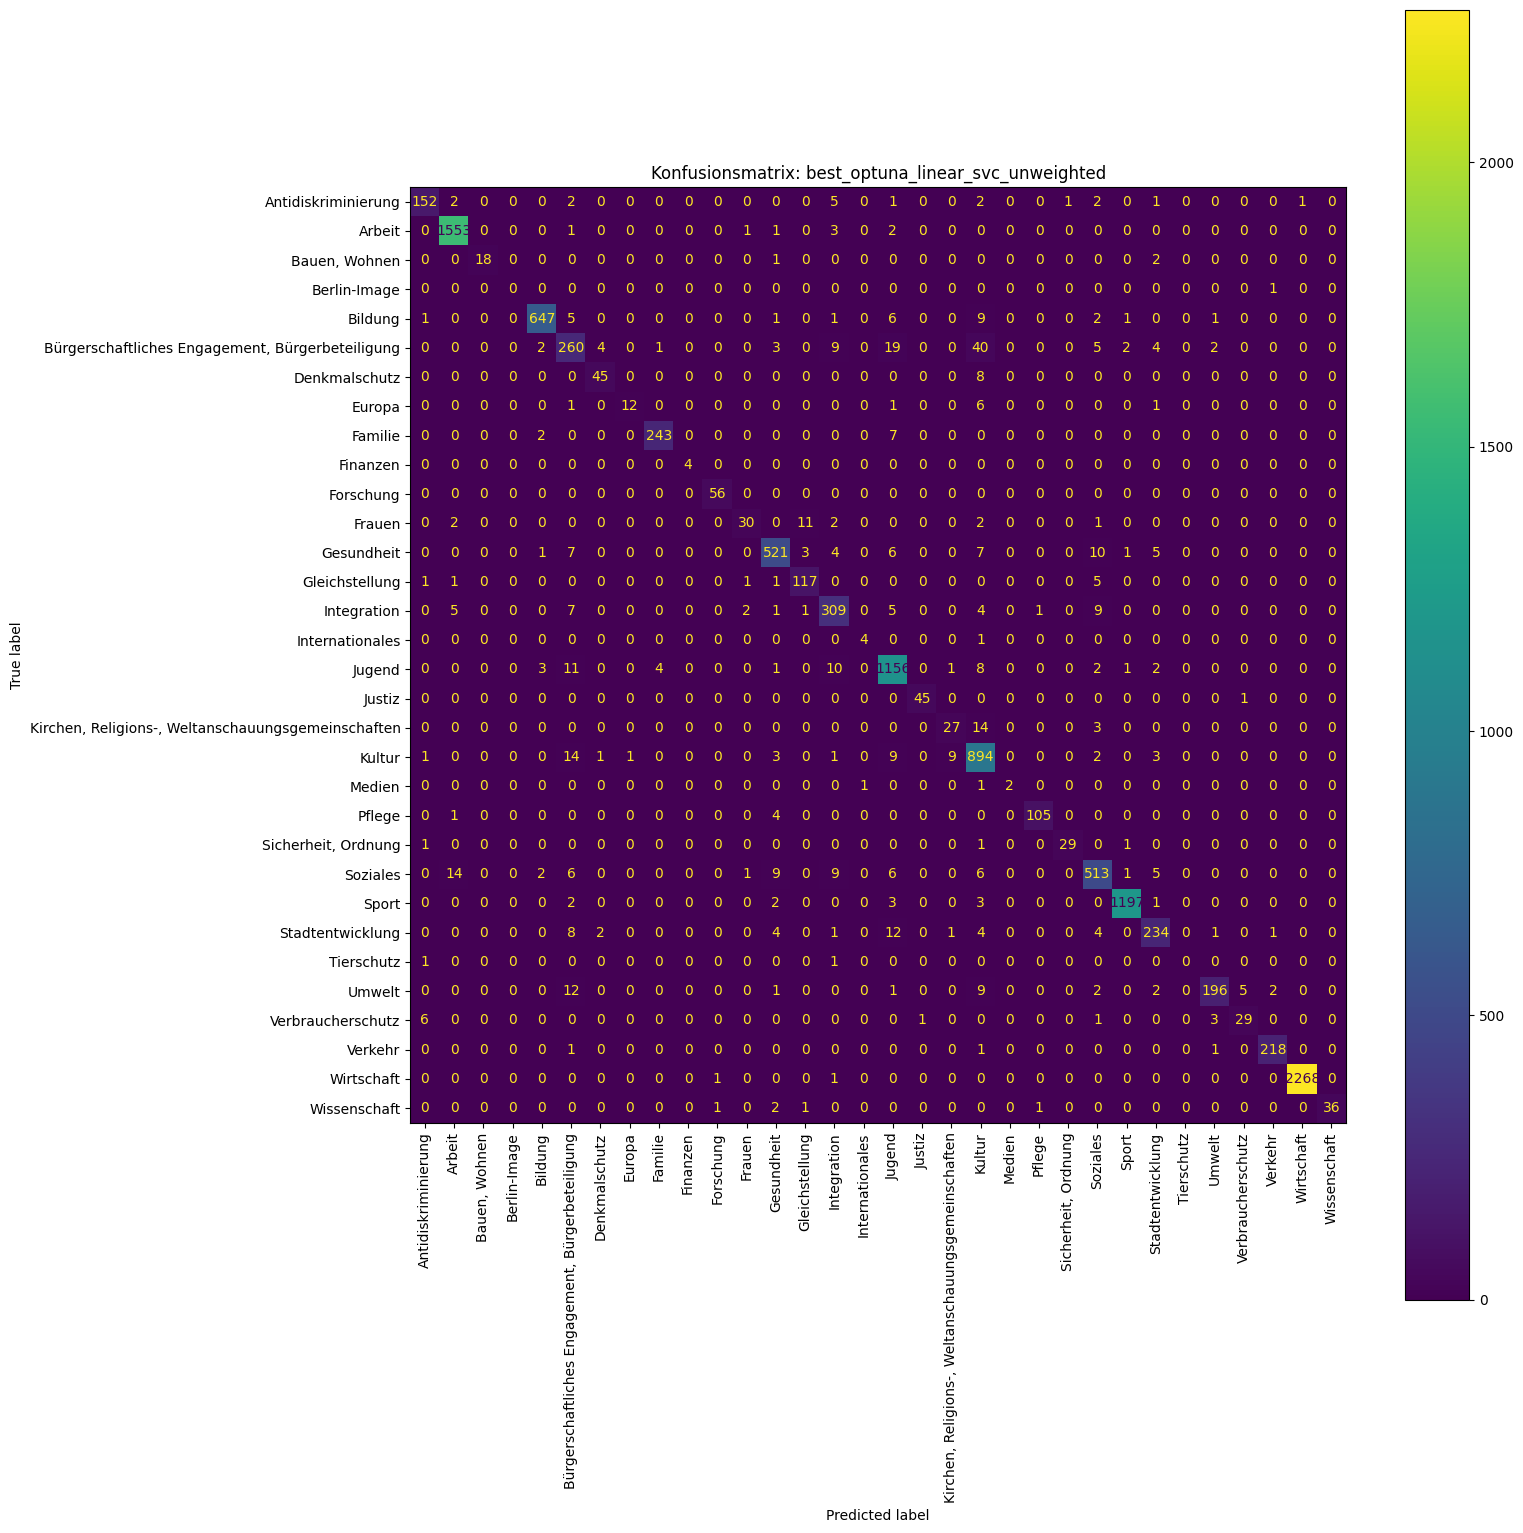

In [19]:
if not final_evaluation_results.empty:
    best_test_model_name = final_evaluation_results.iloc[0]["model_name"]
    plot_confusion_matrix(
        y_test,
        predictions_by_model[best_test_model_name],
        title=f"Konfusionsmatrix: {best_test_model_name}",
        figsize=(16, 16),
    )
else:
    print("Keine Vorhersagen für eine Konfusionsmatrix vorhanden.")


## 8.12. Klassenbezogener Report des Ensemble-Modells anzeigen

Neben dem besten Einzelmodell wird zusätzlich das beste verfügbare Ensemble-Modell betrachtet. Dies ist besonders relevant, wenn das Ensemble im Gesamtranking knapp hinter dem besten Modell liegt. Der klassenbezogene Report zeigt, ob das Ensemble einzelne Politikbereiche anders behandelt und ob es bei kleinen Klassen eine stabilere Alternative sein kann.

In [20]:
if not final_evaluation_results.empty:
    ensemble_model_mask = (
        final_evaluation_results["model_type"]
        .astype(str)
        .str.contains(
            "ensemble",
            case=False,
            na=False,
        )
        | final_evaluation_results["model_name"]
        .astype(str)
        .str.contains(
            "ensemble|voting|hard_voting",
            case=False,
            na=False,
            regex=True,
        )
    )

    ensemble_test_results = (
        final_evaluation_results.loc[ensemble_model_mask]
        .sort_values("test_macro_f1", ascending=False)
        .reset_index(drop=True)
    )

    if ensemble_test_results.empty:
        ensemble_model_name = None
        print(
            "Kein evaluiertes Ensemble-Modell in den finalen "
            "Testergebnissen gefunden."
        )
    else:
        ensemble_model_name = ensemble_test_results.iloc[0]["model_name"]
        print("Bestes Ensemble-Modell:", ensemble_model_name)
        display(
            ensemble_test_results.head(1)
        )

        ensemble_report = classification_reports[ensemble_model_name]
        display(ensemble_report)

        ensemble_low_f1_classes = (
            ensemble_report
            .drop(
                index=["accuracy", "macro avg", "weighted avg"],
                errors="ignore",
            )
            .reset_index(names="politikbereich")
            .sort_values(["f1-score", "support"])
        )

        print("Klassen mit den niedrigsten F1-Werten im Ensemble-Modell:")
        display(ensemble_low_f1_classes.head(10))
else:
    ensemble_model_name = None
    print("Keine Evaluationsergebnisse vorhanden.")

Bestes Ensemble-Modell: hard_voting_tuned_balanced_mix


,model_name,model_type,test_rows,test_accuracy,test_macro_f1,test_weighted_f1,test_balanced_accuracy,prediction_time_seconds,model_path
0,hard_voting_tuned_balanced_mix,scikit-learn,11480,0.949652,0.831458,0.949769,0.826074,1.97,d:\toydev\schwarz-test\models\ensemble\hard_voting_tuned_balanced_mix.joblib


,precision,recall,f1-score,support
Antidiskriminierung,0.905882,0.911243,0.908555,169.000000
Arbeit,0.985942,0.988469,0.987204,1561.000000
"Bauen, Wohnen",1.000000,0.857143,0.923077,21.000000
Berlin-Image,0.000000,0.000000,0.000000,1.000000
Bildung,0.978884,0.962908,0.970830,674.000000
"Bürgerschaftliches Engagement, Bürgerbeteiligung",0.748634,0.780627,0.764296,351.000000
Denkmalschutz,0.886792,0.886792,0.886792,53.000000
Europa,0.684211,0.619048,0.650000,21.000000
Familie,0.975904,0.964286,0.970060,252.000000
Finanzen,1.000000,1.000000,1.000000,4.000000


Klassen mit den niedrigsten F1-Werten im Ensemble-Modell:


,politikbereich,precision,recall,f1-score,support
3,Berlin-Image,0.000000,0.000000,0.000000,1.0
26,Tierschutz,0.000000,0.000000,0.000000,2.0
18,"Kirchen, Religions-, Weltanschauungsgemeinschaften",0.574074,0.704545,0.632653,44.0
7,Europa,0.684211,0.619048,0.650000,21.0
20,Medien,1.000000,0.500000,0.666667,4.0
11,Frauen,0.727273,0.666667,0.695652,48.0
15,Internationales,0.666667,0.800000,0.727273,5.0
5,"Bürgerschaftliches Engagement, Bürgerbeteiligung",0.748634,0.780627,0.764296,351.0
28,Verbraucherschutz,0.820513,0.800000,0.810127,40.0
14,Integration,0.850416,0.892442,0.870922,344.0


## 8.13. Konfusionsmatrix des Ensemble-Modells

Die Konfusionsmatrix des Ensemble-Modells wird separat angezeigt, um typische Verwechslungen mit dem besten Einzelmodell vergleichen zu können. Dadurch wird sichtbar, ob das Ensemble dieselben Fehler macht oder bestimmte Politikbereiche anders zuordnet.

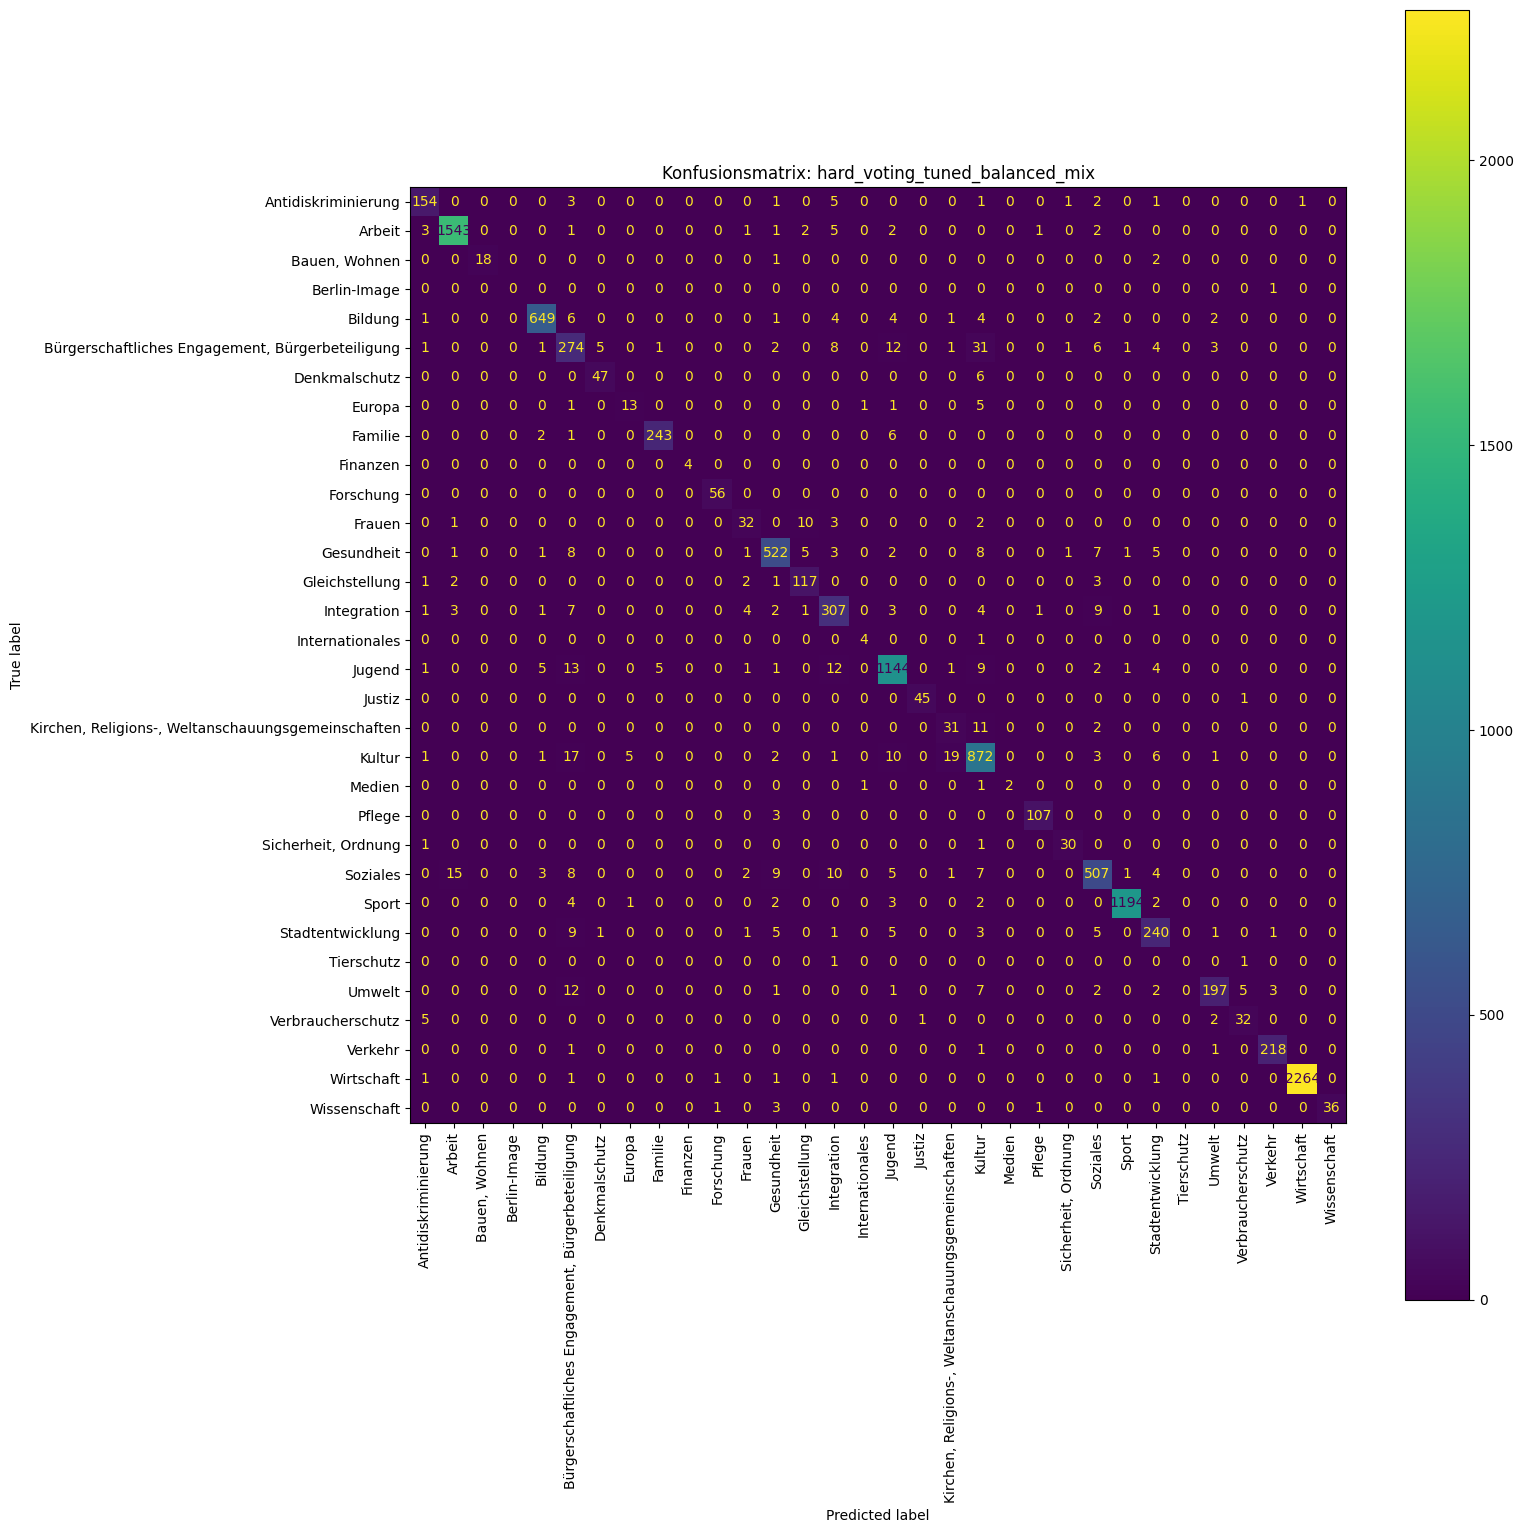

In [21]:
if (
    "ensemble_model_name" in globals()
    and ensemble_model_name is not None
    and ensemble_model_name in predictions_by_model
):
    plot_confusion_matrix(
        y_test,
        predictions_by_model[ensemble_model_name],
        title=f"Konfusionsmatrix: {ensemble_model_name}",
        figsize=(16, 16),
    )
else:
    print(
        "Keine Vorhersagen für eine Ensemble-Konfusionsmatrix vorhanden."
    )

**Vergleich des besten Einzelmodells mit dem Ensemble-Modell.**

Der klassenbezogene Vergleich zeigt, dass das Ensemble nicht alle Schwächen des besten Einzelmodells behebt. Besonders die extrem seltenen Klassen `Berlin-Image` und `Tierschutz` bleiben in beiden Modellen problematisch. Bei einem Support von nur 1 bzw. 2 Beobachtungen im Testdatensatz sind diese Werte allerdings sehr instabil und sollten nicht überinterpretiert werden.

Bei mehreren kleinen und mittleren Klassen verändert das Ensemble jedoch das Fehlerprofil. Für `Bürgerschaftliches Engagement, Bürgerbeteiligung` steigt der F1-Score leicht von 0,756 auf 0,764. Auch `Verbraucherschutz` verbessert sich deutlich von 0,773 auf 0,810. `Integration` erscheint im Ensemble nicht mehr unter den schwächsten Problemklassen und erreicht einen F1-Score von 0,871. Das deutet darauf hin, dass das Ensemble bestimmte mittlere Klassen robuster erkennt.

Gleichzeitig verschlechtert sich das Ensemble bei einigen seltenen Klassen. Bei `Kirchen, Religions-, Weltanschauungsgemeinschaften` sinkt der F1-Score von 0,659 auf 0,633. Auch `Europa` fällt von 0,706 auf 0,650 und `Frauen` von 0,723 auf 0,696. In diesen Fällen erhöht das Ensemble teilweise den Recall, verliert aber stärker an Precision. Das bedeutet, dass diese Klassen zwar häufiger erkannt werden, aber auch häufiger fälschlich vorhergesagt werden.

Insgesamt zeigt der Vergleich, dass das Ensemble kein eindeutig überlegenes Modell ist. Es verändert vor allem den Trade-off zwischen Precision und Recall. Für einige Klassen verbessert es die Erkennung, für andere führt es zu mehr Fehlklassifikationen. Deshalb sollte das Ensemble eher als zusätzliche robuste Modellvariante betrachtet werden, während das beste Einzelmodell weiterhin die klarere Hauptentscheidung bleibt, sofern es insgesamt die bessere Macro-F1 auf dem Testdatensatz erreicht.

## 8.14. Grenzen der bisherigen Modellierung und Verbesserungsmöglichkeiten

Die finale Evaluation zeigt den aktuellen Stand der Modellierung, deckt aber noch nicht alle sinnvollen Modell- und Optimierungsstrategien ab. Aufgrund der begrenzten Bearbeitungszeit sowie der verfügbaren CPU- und GPU-Kapazität konnten einige weiterführende Experimente nicht vollständig umgesetzt werden.

Neben den bereits geprüften klassischen Modellen, fastText, BERT-Vorbereitungen und CatBoost wären weitere moderne Ansätze interessant gewesen. Besonders relevant wäre ein Vergleich mit **AutoGluon MultiModalPredictor**, da dieses Framework Text-, kategoriale und numerische Merkmale gemeinsam modellieren kann.

Darüber hinaus wären neuronale Netze für die nicht-textuellen Merkmale interessant gewesen. Ein Feedforward Neural Network auf numerischen und kategorial kodierten Merkmalen könnte zeigen, ob Informationen wie `art`, `jahr`, `betrag` oder institutionelle Merkmale einen eigenständigen Beitrag zur Klassifikation leisten. Auch hybride Architekturen, die Textrepräsentationen mit strukturierten Merkmalen kombinieren, wären eine sinnvolle Erweiterung.

Eine vollständige Hyperparameteroptimierung wurde nicht für alle Modellkandidaten durchgeführt. Für klassische Modelle wie `SGDClassifier` und fastText konnten erste Optuna-basierte Varianten geprüft werden. Für langsamere Modelle wie CatBoost, BERT, neuronale Netze wäre jedoch eine breitere und systematischere Suche notwendig gewesen.

Insbesondere für neuronale Netze oder andere iterative Modelle hätte zusätzlich eine ressourcenschonende Tuning-Strategie wie Hyperband getestet werden können. Hyperband bzw. verwandte Pruning-Verfahren wie `HyperbandPruner` oder `SuccessiveHalvingPruner` in Optuna können schwache Trials früh abbrechen, sobald sich während des Trainings zeigt, dass sie wahrscheinlich keine konkurrenzfähige Leistung erreichen. Dadurch könnten bei begrenzter Rechenzeit mehr Hyperparameterkombinationen geprüft werden.

Ein weiterer Verbesserungsbereich betrifft die Robustheitsprüfung. Zusätzlich zur bisherigen stratifizierten Cross-Validation wäre eine Analyse sinnvoll, wie stabil die Modelle über einzelne Jahre, seltene Klassen und unterschiedliche Empfängergruppen hinweg sind. Auch eine detailliertere Fehleranalyse pro Politikbereich könnte zeigen, welche Klassen systematisch verwechselt werden.

Schließlich könnten die Feature-Experimente weiter ausgebaut werden. Für die stärksten Modellkandidaten wären weitere Varianten sinnvoll, zum Beispiel ohne adressbezogene Merkmale, mit stärker reduzierten Empfängerinformationen oder mit alternativen Textrepräsentationen. Dadurch ließe sich besser beurteilen, ob die Modelle tatsächlich inhaltliche Muster des Förderzwecks lernen oder teilweise stark von institutionellen Identifikationsmerkmalen abhängen.

Zusammenfassend ist das aktuelle Ergebnis als belastbare erste Modellierungsbasis zu verstehen. Für eine produktionsnahe Lösung sollten zusätzliche Modellfamilien, neuronale Netze für strukturierte Merkmale, breitere Hyperparameteroptimierung mit Pruning, Ensemble-Ansätze, Robustheitsanalysen und eine vertiefte Fehleranalyse ergänzt werden.
